In [2]:
from dotenv import load_dotenv
load_dotenv()
from langgraph.graph import START,END,StateGraph
from typing import  TypedDict
from langchain_ollama import ChatOllama

c:\projects\Langraph\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##    start - parallel(SR,Bounday%,boundpb)-> summary

In [13]:
llm=ChatOllama(model='gemma4:31b-cloud' )   

In [14]:
class Batsman(TypedDict):
   run:int
   balls:int
   fours:int
   sixes:int
   SR:float
   bpb:float
   bpercent:float


In [24]:
def calculate_SR(batsman:Batsman)->Batsman:
    batsman['SR']=(batsman['run']/batsman['balls'])*100
    return {'SR':batsman['SR']}

In [25]:
def calculate_bpb(batsman:Batsman)->Batsman:
    batsman['bpb']=batsman['balls']/(batsman['fours']+batsman['sixes'])
    return {'bpb':batsman['bpb']}

In [33]:
def calculate_bpercent(batsman:Batsman)->Batsman:
    batsman['bpercent']=(batsman['fours']*4+batsman['sixes']*6)/batsman['run']*100
    return {'bpercent':batsman['bpercent']}

In [34]:
def summarize(batsman:Batsman)->str:
    summary=f"Batsman scored {batsman['run']} runs in {batsman['balls']} balls with a strike rate of {batsman['SR']:.2f}. He hit {batsman['fours']} fours and {batsman['sixes']} sixes. The balls per boundary is {batsman['bpb']:.2f} and the percentage of balls that were not boundaries is {batsman['bpercent']:.2f}%."
    return  {'summary':summary}

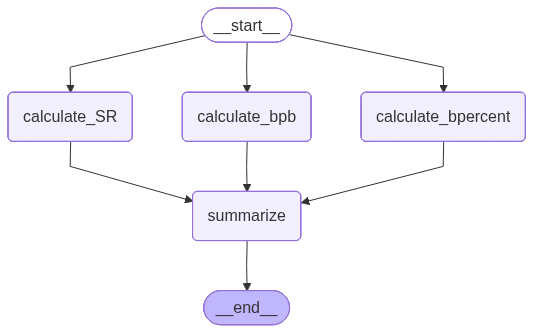

In [35]:
graph=StateGraph(Batsman)
graph.add_node('calculate_SR',calculate_SR)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_bpercent',calculate_bpercent)
graph.add_node('summarize',summarize)
graph.add_edge(START,'calculate_SR')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_bpercent')
graph.add_edge('calculate_SR','summarize')
graph.add_edge('calculate_bpb','summarize')
graph.add_edge('calculate_bpercent','summarize')
graph.add_edge('summarize',END)
workflow=graph.compile()
workflow

In [36]:
response=workflow.invoke({'run':50,'balls':25,'fours':4,'sixes':5})

In [37]:
response

{'run': 50,
 'balls': 25,
 'fours': 4,
 'sixes': 5,
 'SR': 200.0,
 'bpb': 2.7777777777777777,
 'bpercent': 92.0}